# 03 Model Comparison Analysis

compares the four experiments:
1. Baseline CNN + Standard Cross-Entropy Loss  
2. ResNet18 + Standard Cross-Entropy Loss  
3. ResNet18 + Class-weighted Cross-Entropy Loss  
4. ResNet18 + Ordinal-aware Weighted Loss


In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Src folder:", SRC_DIR)
print("Src exists:", SRC_DIR.exists())


Project root: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1
Src folder: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\src
Src exists: True


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from config import RESULT_DIR, FIGURE_DIR

print("Result directory:", RESULT_DIR)
print("Figure directory:", FIGURE_DIR)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


Result directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\results
Figure directory: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures


## 1. Load overall test metrics

This section loads the test metrics produced by each evaluation script.


In [3]:
metric_files = {
    "Baseline CNN + Standard CE": RESULT_DIR / "baseline_test_metrics.csv",
    "ResNet18 + Standard CE": RESULT_DIR / "resnet18_test_metrics.csv",
    "ResNet18 + Class-weighted CE": RESULT_DIR / "resnet18_classweighted_test_metrics.csv",
    "ResNet18 + Ordinal-aware Loss": RESULT_DIR / "resnet18_ordinal_test_metrics.csv",
}

overall_rows = []

for display_name, path in metric_files.items():
    if path.exists():
        df = pd.read_csv(path)
        row = df.iloc[0].to_dict()
        row["experiment"] = display_name
        overall_rows.append(row)
    else:
        print(f"Missing file: {path}")

overall_df = pd.DataFrame(overall_rows)

if not overall_df.empty:
    display(overall_df)
else:
    print("No metric files were loaded.")


,model,loss,accuracy,macro_f1,weighted_f1,mae,qwk,total_errors,adjacent_errors,distant_errors,adjacent_error_rate_among_errors,distant_error_rate_among_errors,experiment
0,BaselineCNN,CrossEntropyLoss,0.459184,0.373347,0.418762,1.020408,0.505671,159,81,78,0.509434,0.490566,Baseline CNN + Standard CE
1,resnet18,CrossEntropyLoss,0.717687,0.701013,0.714049,0.391156,0.817549,83,62,21,0.746988,0.253012,ResNet18 + Standard CE
2,resnet18_classweighted,Class-weighted CrossEntropyLoss,0.683673,0.685369,0.691945,0.455782,0.792050,93,60,33,0.645161,0.354839,ResNet18 + Class-weighted CE
3,resnet18_ordinal,Ordinal-aware weighted loss,0.710884,0.703587,0.711742,0.387755,0.824595,85,64,21,0.752941,0.247059,ResNet18 + Ordinal-aware Loss


## 2. Final comparison table

This table is suitable for the presentation results slide.


In [4]:
columns_to_show = [
    "experiment",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "mae",
    "qwk",
    "adjacent_error_rate_among_errors",
    "distant_error_rate_among_errors",
]

if not overall_df.empty:
    final_comparison = overall_df[columns_to_show].copy()

    final_comparison = final_comparison.rename(columns={
        "experiment": "Experiment",
        "accuracy": "Accuracy",
        "macro_f1": "Macro F1",
        "weighted_f1": "Weighted F1",
        "mae": "MAE",
        "qwk": "QWK",
        "adjacent_error_rate_among_errors": "Adjacent Error Rate",
        "distant_error_rate_among_errors": "Distant Error Rate",
    })

    numeric_cols = [
        "Accuracy",
        "Macro F1",
        "Weighted F1",
        "MAE",
        "QWK",
        "Adjacent Error Rate",
        "Distant Error Rate",
    ]

    final_comparison[numeric_cols] = final_comparison[numeric_cols].round(4)

    display(final_comparison)

    output_path = RESULT_DIR / "final_model_comparison.csv"
    final_comparison.to_csv(output_path, index=False)
    print("Saved final comparison table to:", output_path)
else:
    print("Overall metrics are not available.")


,Experiment,Accuracy,Macro F1,Weighted F1,MAE,QWK,Adjacent Error Rate,Distant Error Rate
0,Baseline CNN + Standard CE,0.4592,0.3733,0.4188,1.0204,0.5057,0.5094,0.4906
1,ResNet18 + Standard CE,0.7177,0.7010,0.7140,0.3912,0.8175,0.7470,0.2530
2,ResNet18 + Class-weighted CE,0.6837,0.6854,0.6919,0.4558,0.7921,0.6452,0.3548
3,ResNet18 + Ordinal-aware Loss,0.7109,0.7036,0.7117,0.3878,0.8246,0.7529,0.2471


Saved final comparison table to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\results\final_model_comparison.csv


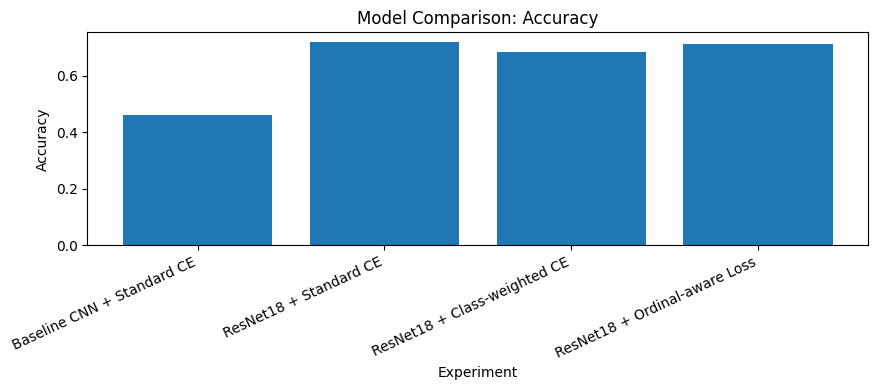

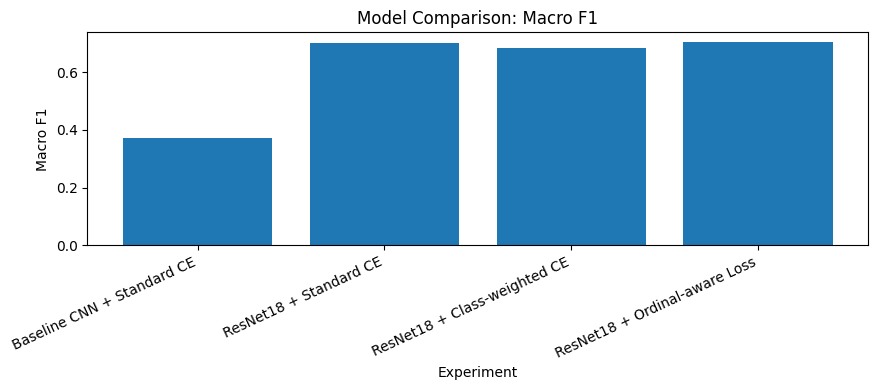

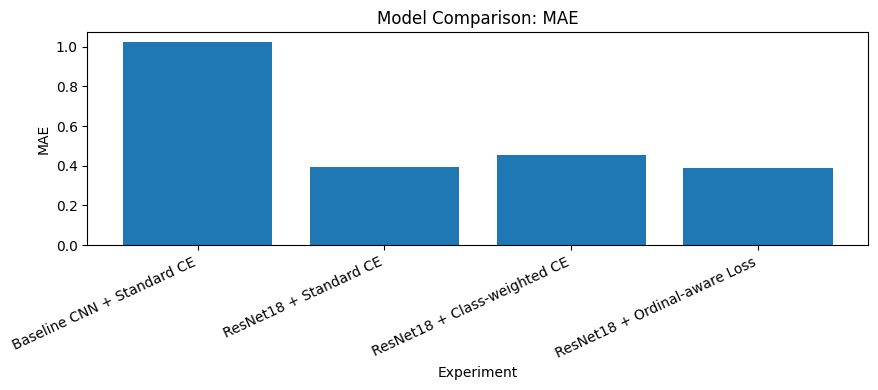

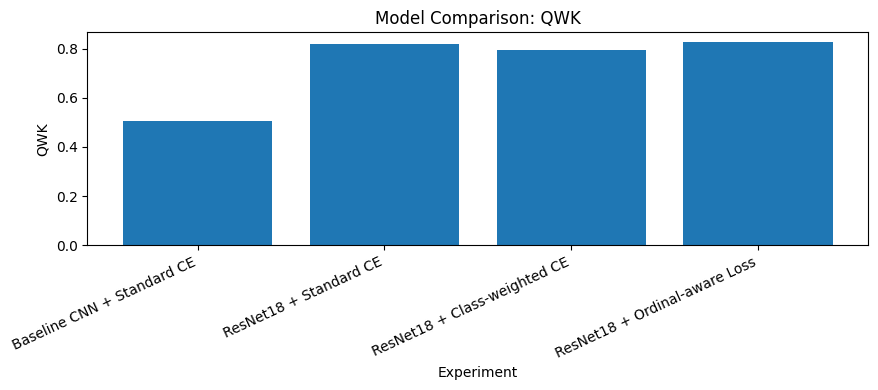

In [5]:
if not overall_df.empty:
    plot_df = final_comparison.copy()

    metrics = ["Accuracy", "Macro F1", "MAE", "QWK"]

    for metric in metrics:
        plt.figure(figsize=(9, 4))
        plt.bar(plot_df["Experiment"], plot_df[metric])
        plt.title(f"Model Comparison: {metric}")
        plt.xlabel("Experiment")
        plt.ylabel(metric)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("Overall metrics are not available.")


## 3. Per-class F1-score comparison

This chart is important because the baseline model failed to predict the Mild class.


In [6]:
per_class_files = {
    "Baseline CNN + Standard CE": RESULT_DIR / "baseline_per_class_metrics.csv",
    "ResNet18 + Standard CE": RESULT_DIR / "resnet18_per_class_metrics.csv",
    "ResNet18 + Class-weighted CE": RESULT_DIR / "resnet18_classweighted_per_class_metrics.csv",
    "ResNet18 + Ordinal-aware Loss": RESULT_DIR / "resnet18_ordinal_per_class_metrics.csv",
}

per_class_rows = []

for experiment, path in per_class_files.items():
    if path.exists():
        df = pd.read_csv(path)
        df["experiment"] = experiment
        per_class_rows.append(df)
    else:
        print(f"Missing file: {path}")

if per_class_rows:
    per_class_all = pd.concat(per_class_rows, ignore_index=True)
    display(per_class_all)
else:
    print("No per-class files were loaded.")


,label,class_name,precision,recall,f1_score,support,experiment
0,0,Normal,0.513043,0.648352,0.572816,91,Baseline CNN + Standard CE
1,1,Doubtful,0.516667,0.352273,0.418919,88,Baseline CNN + Standard CE
2,2,Mild,0.000000,0.000000,0.000000,38,Baseline CNN + Standard CE
3,3,Moderate,0.413793,0.342857,0.375000,35,Baseline CNN + Standard CE
4,4,Severe,0.366667,0.785714,0.500000,42,Baseline CNN + Standard CE
5,0,Normal,0.767677,0.835165,0.800000,91,ResNet18 + Standard CE
6,1,Doubtful,0.645833,0.704545,0.673913,88,ResNet18 + Standard CE
7,2,Mild,0.533333,0.421053,0.470588,38,ResNet18 + Standard CE
8,3,Moderate,0.750000,0.857143,0.800000,35,ResNet18 + Standard CE
9,4,Severe,0.931034,0.642857,0.760563,42,ResNet18 + Standard CE


experiment,Baseline CNN + Standard CE,ResNet18 + Class-weighted CE,ResNet18 + Ordinal-aware Loss,ResNet18 + Standard CE
class_name,,,,
Normal,0.5728,0.7529,0.7826,0.8000
Doubtful,0.4189,0.6548,0.6703,0.6739
Mild,0.0000,0.4583,0.4737,0.4706
Moderate,0.3750,0.8108,0.8267,0.8000
Severe,0.5000,0.7500,0.7647,0.7606


Saved per-class F1 comparison to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\results\per_class_f1_comparison.csv


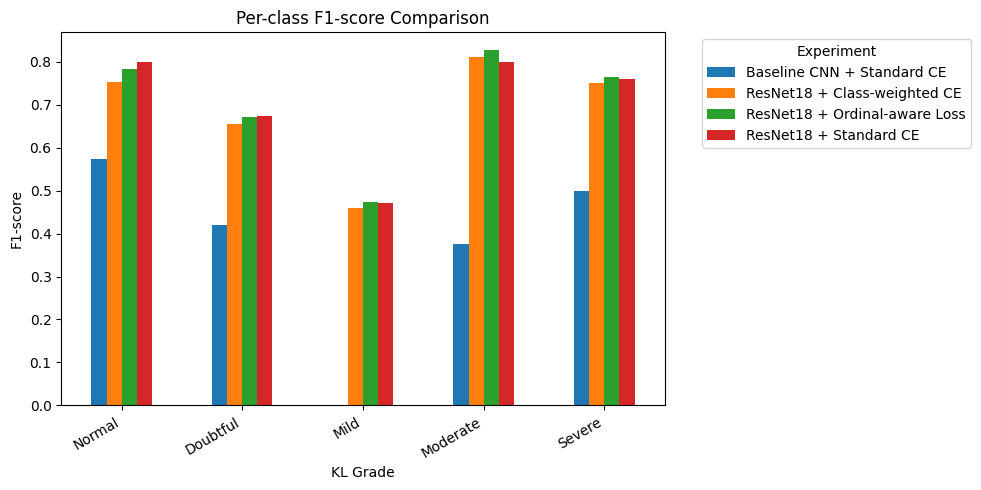

Saved per-class F1 chart to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\per_class_f1_comparison.png


In [7]:
if per_class_rows:
    f1_pivot = per_class_all.pivot_table(
        index="class_name",
        columns="experiment",
        values="f1_score",
        aggfunc="first"
    )

    class_order = ["Normal", "Doubtful", "Mild", "Moderate", "Severe"]
    f1_pivot = f1_pivot.reindex(class_order)

    display(f1_pivot.round(4))

    output_path = RESULT_DIR / "per_class_f1_comparison.csv"
    f1_pivot.to_csv(output_path)
    print("Saved per-class F1 comparison to:", output_path)

    ax = f1_pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_title("Per-class F1-score Comparison")
    ax.set_xlabel("KL Grade")
    ax.set_ylabel("F1-score")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Experiment", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    output_fig = FIGURE_DIR / "per_class_f1_comparison.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved per-class F1 chart to:", output_fig)
else:
    print("Per-class metrics are not available.")


## 4. Error distance comparison

Because KL grades are ordinal, we compare adjacent errors and distant errors.

- Adjacent error: prediction differs from the true label by 1 grade.
- Distant error: prediction differs from the true label by 2 or more grades.


,Experiment,Adjacent Error Rate,Distant Error Rate
0,Baseline CNN + Standard CE,0.5094,0.4906
1,ResNet18 + Standard CE,0.7470,0.2530
2,ResNet18 + Class-weighted CE,0.6452,0.3548
3,ResNet18 + Ordinal-aware Loss,0.7529,0.2471


Saved error distance comparison to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\results\error_distance_comparison.csv


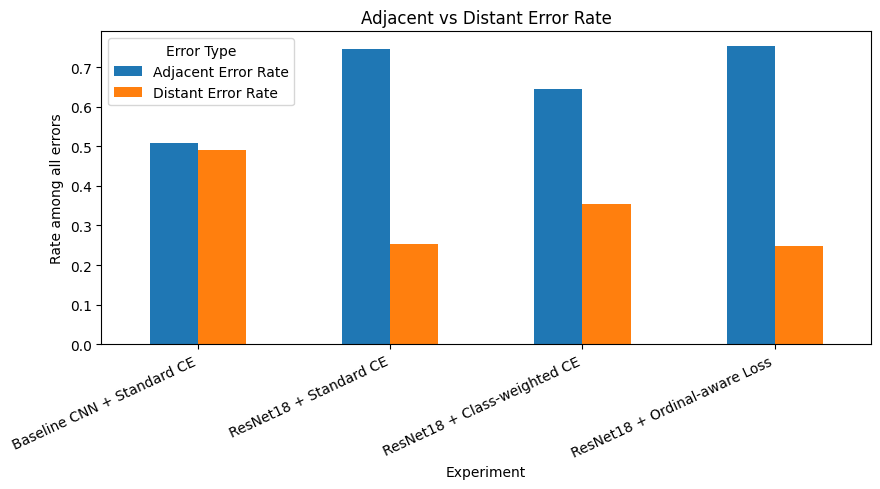

Saved error distance chart to: C:\Users\yuely\OneDrive\Desktop\cs760\760-Group1\outputs\figures\error_distance_comparison.png


In [8]:
if not overall_df.empty:
    error_df = final_comparison[
        ["Experiment", "Adjacent Error Rate", "Distant Error Rate"]
    ].copy()

    display(error_df)

    output_path = RESULT_DIR / "error_distance_comparison.csv"
    error_df.to_csv(output_path, index=False)
    print("Saved error distance comparison to:", output_path)

    error_plot_df = error_df.set_index("Experiment")
    ax = error_plot_df.plot(kind="bar", figsize=(9, 5))
    ax.set_title("Adjacent vs Distant Error Rate")
    ax.set_xlabel("Experiment")
    ax.set_ylabel("Rate among all errors")
    plt.xticks(rotation=25, ha="right")
    plt.legend(title="Error Type")
    plt.tight_layout()

    output_fig = FIGURE_DIR / "error_distance_comparison.png"
    plt.savefig(output_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved error distance chart to:", output_fig)
else:
    print("Overall metrics are not available.")


## 5. Confusion matrices

Use these figures to explain where the models make mistakes.



Baseline CNN


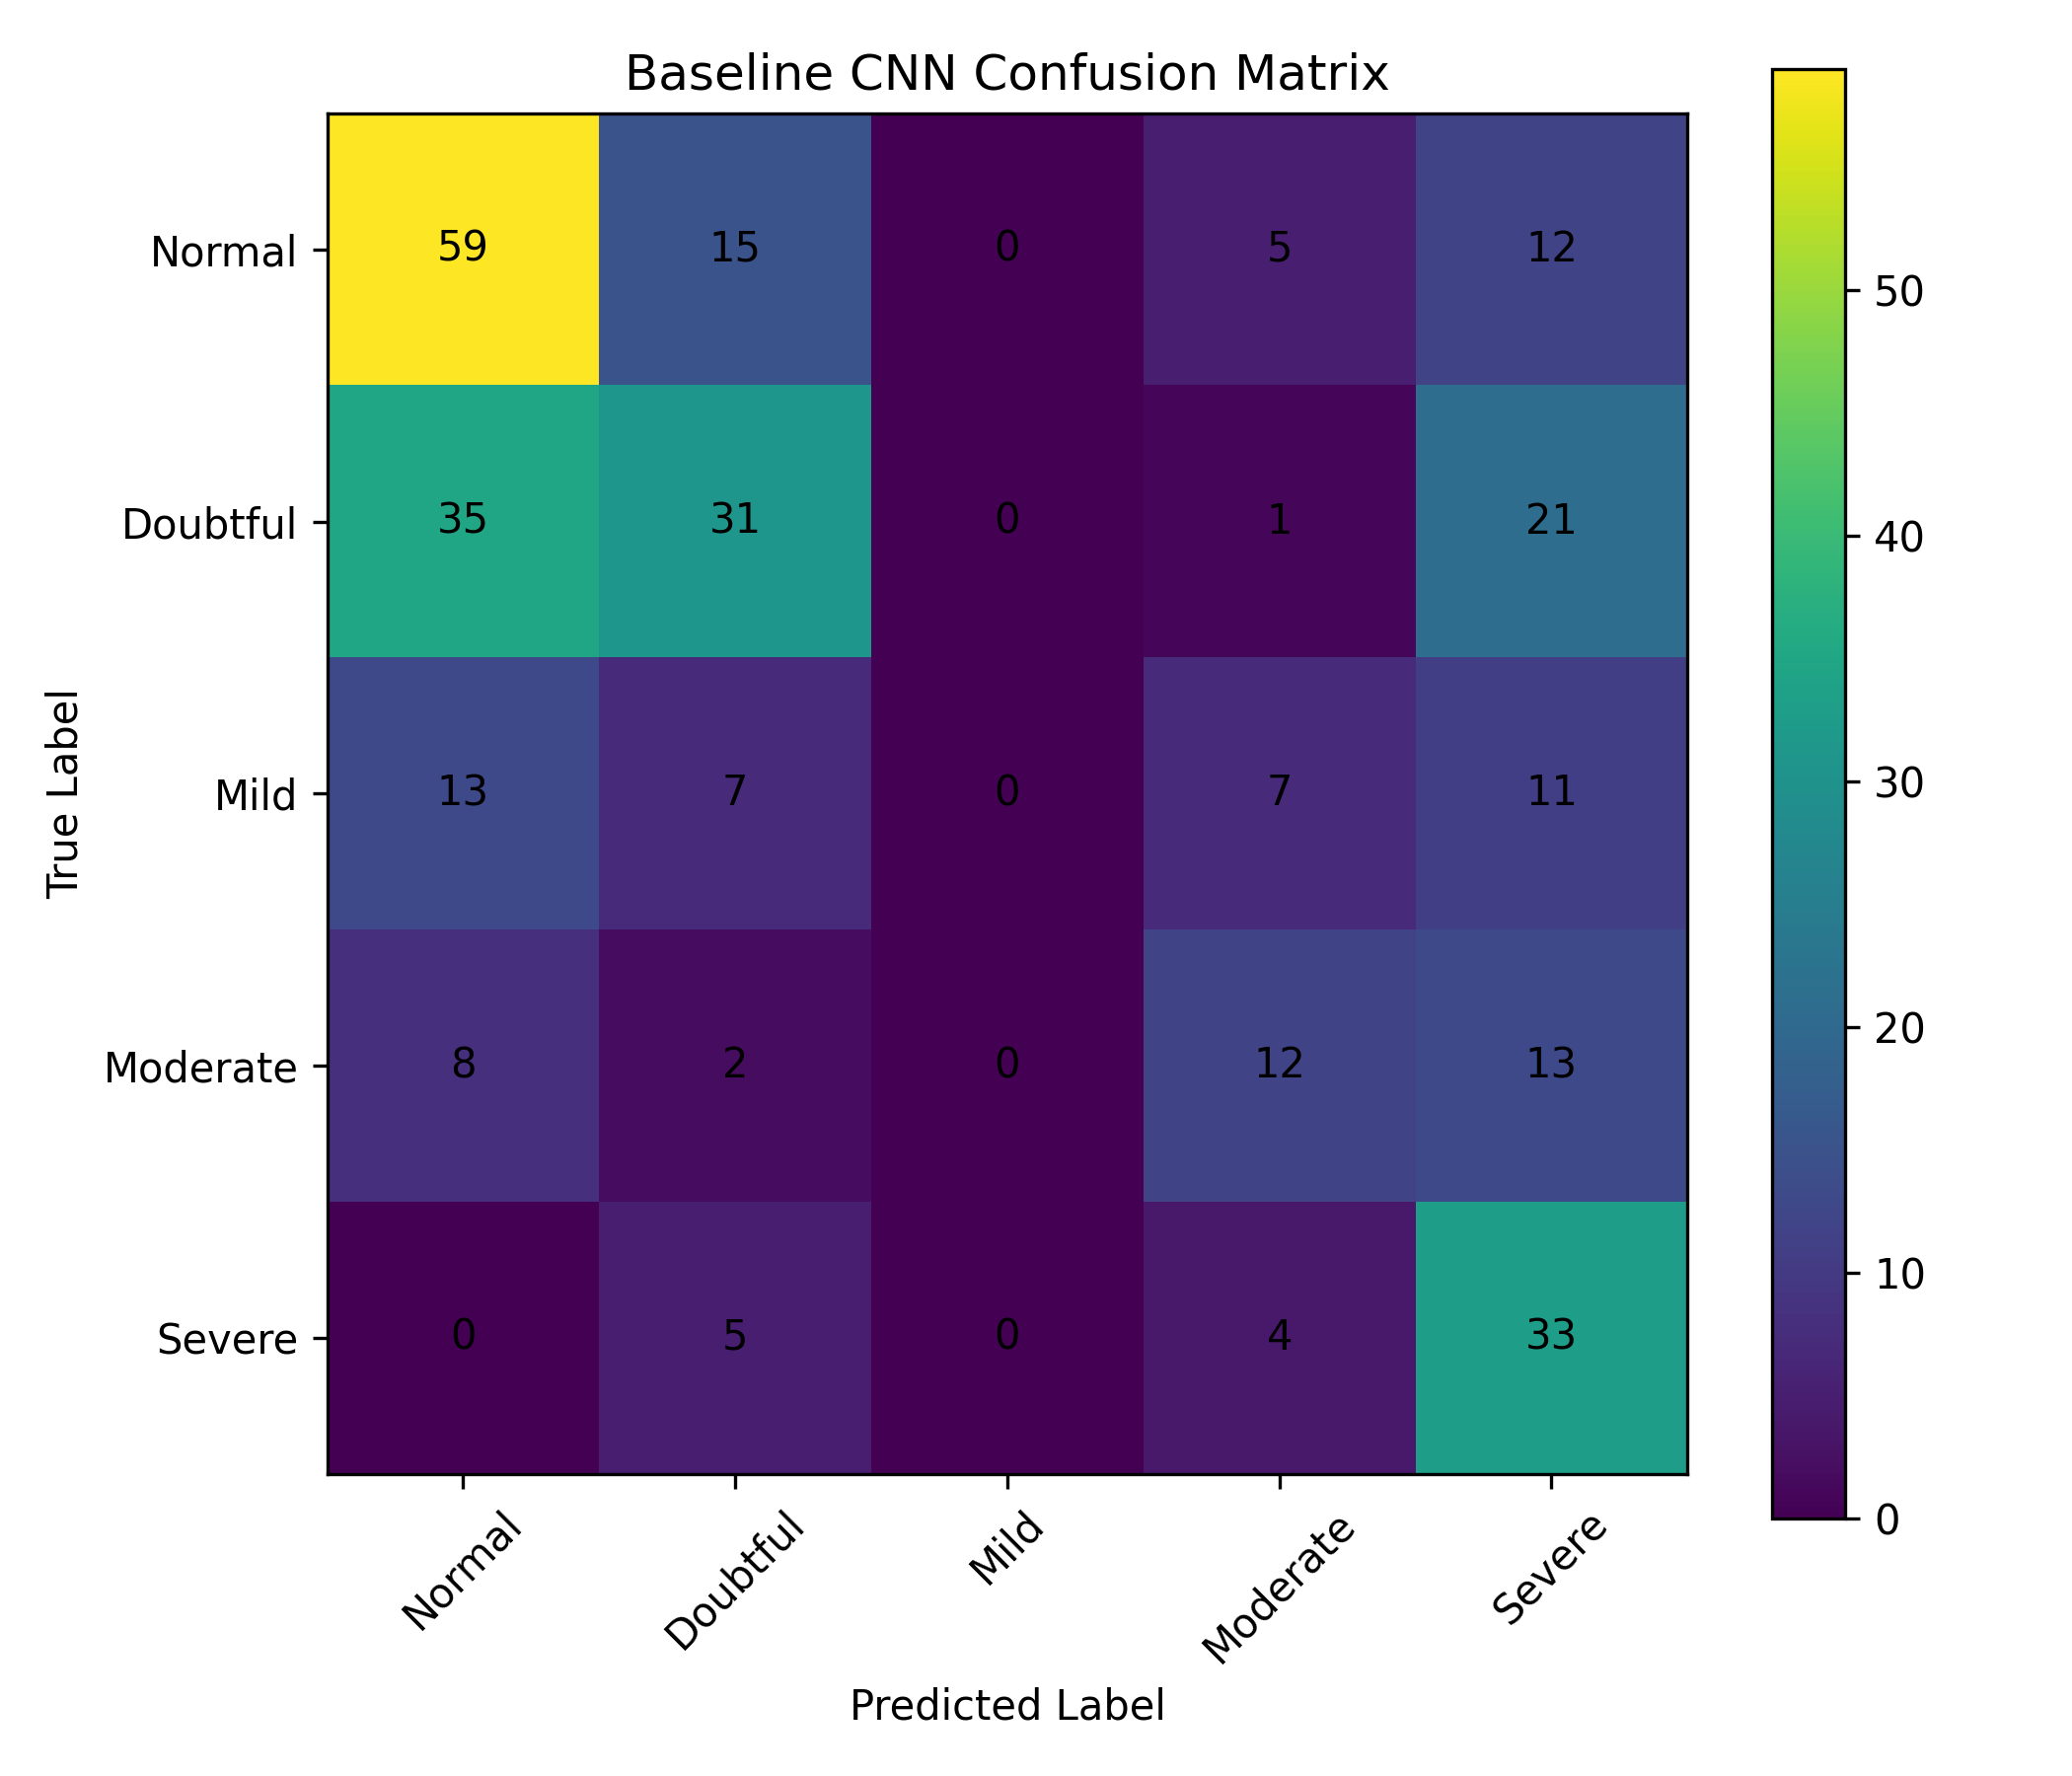


ResNet18 + Standard CE


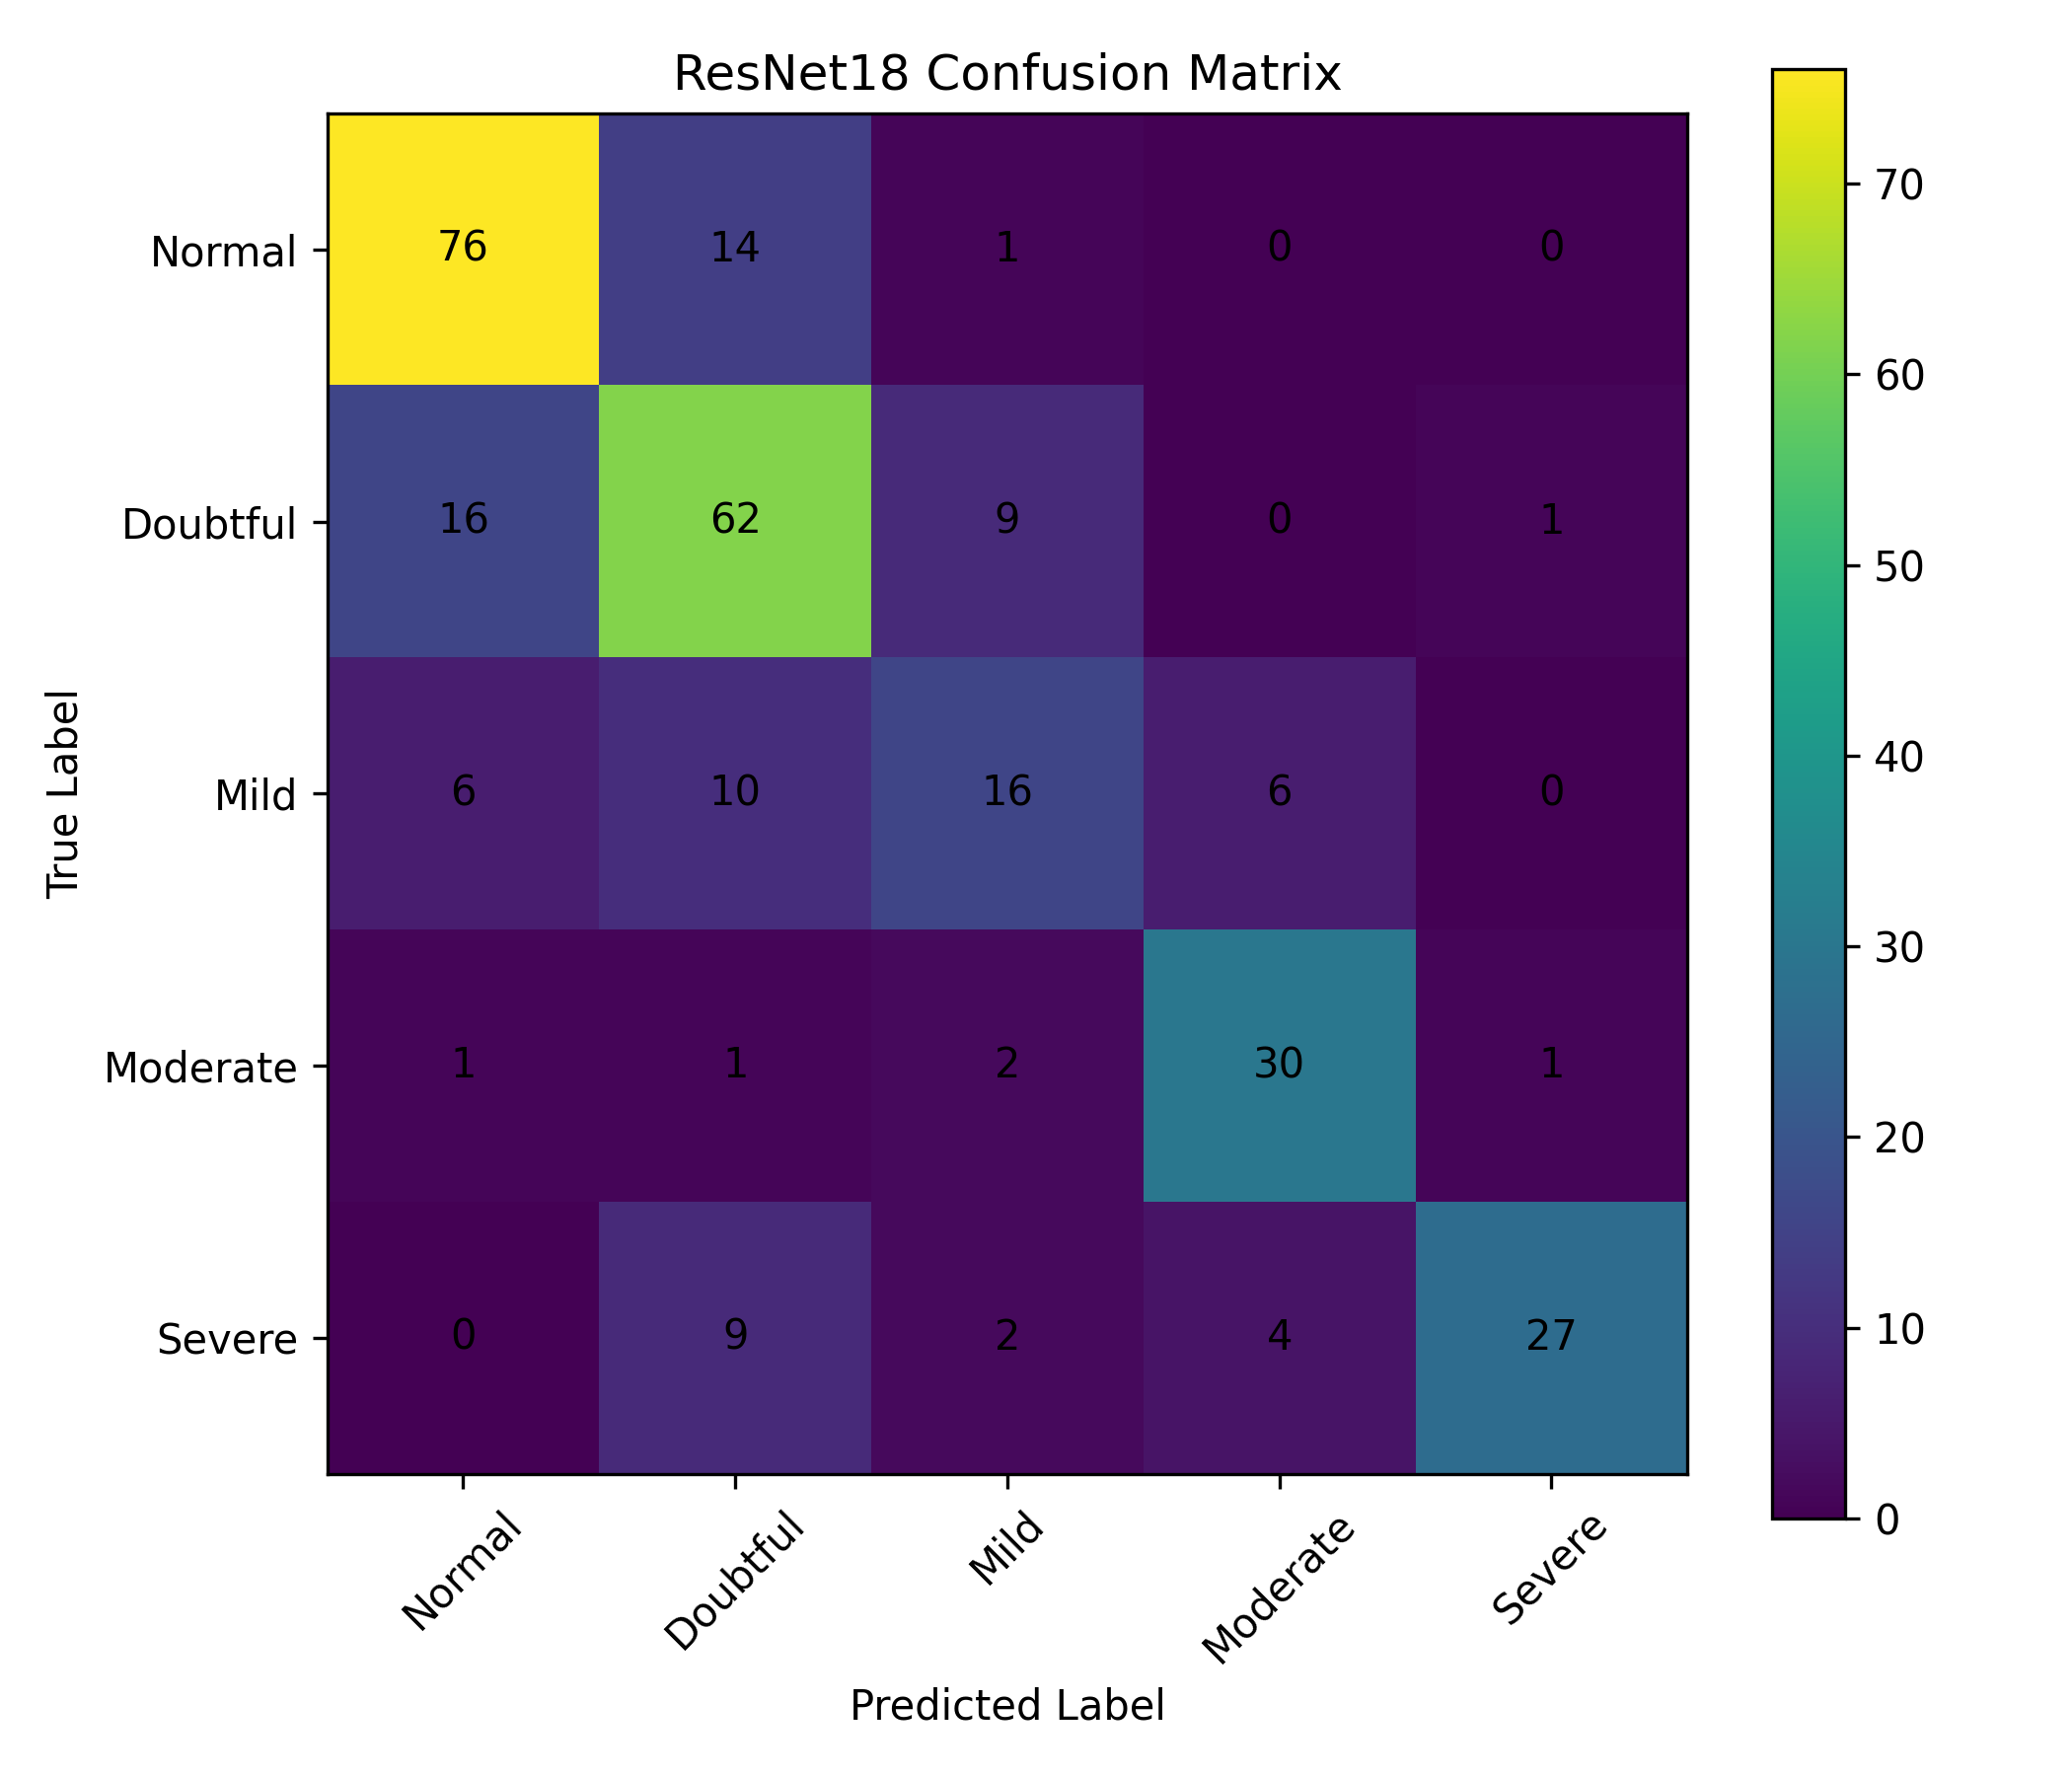


ResNet18 + Class-weighted CE


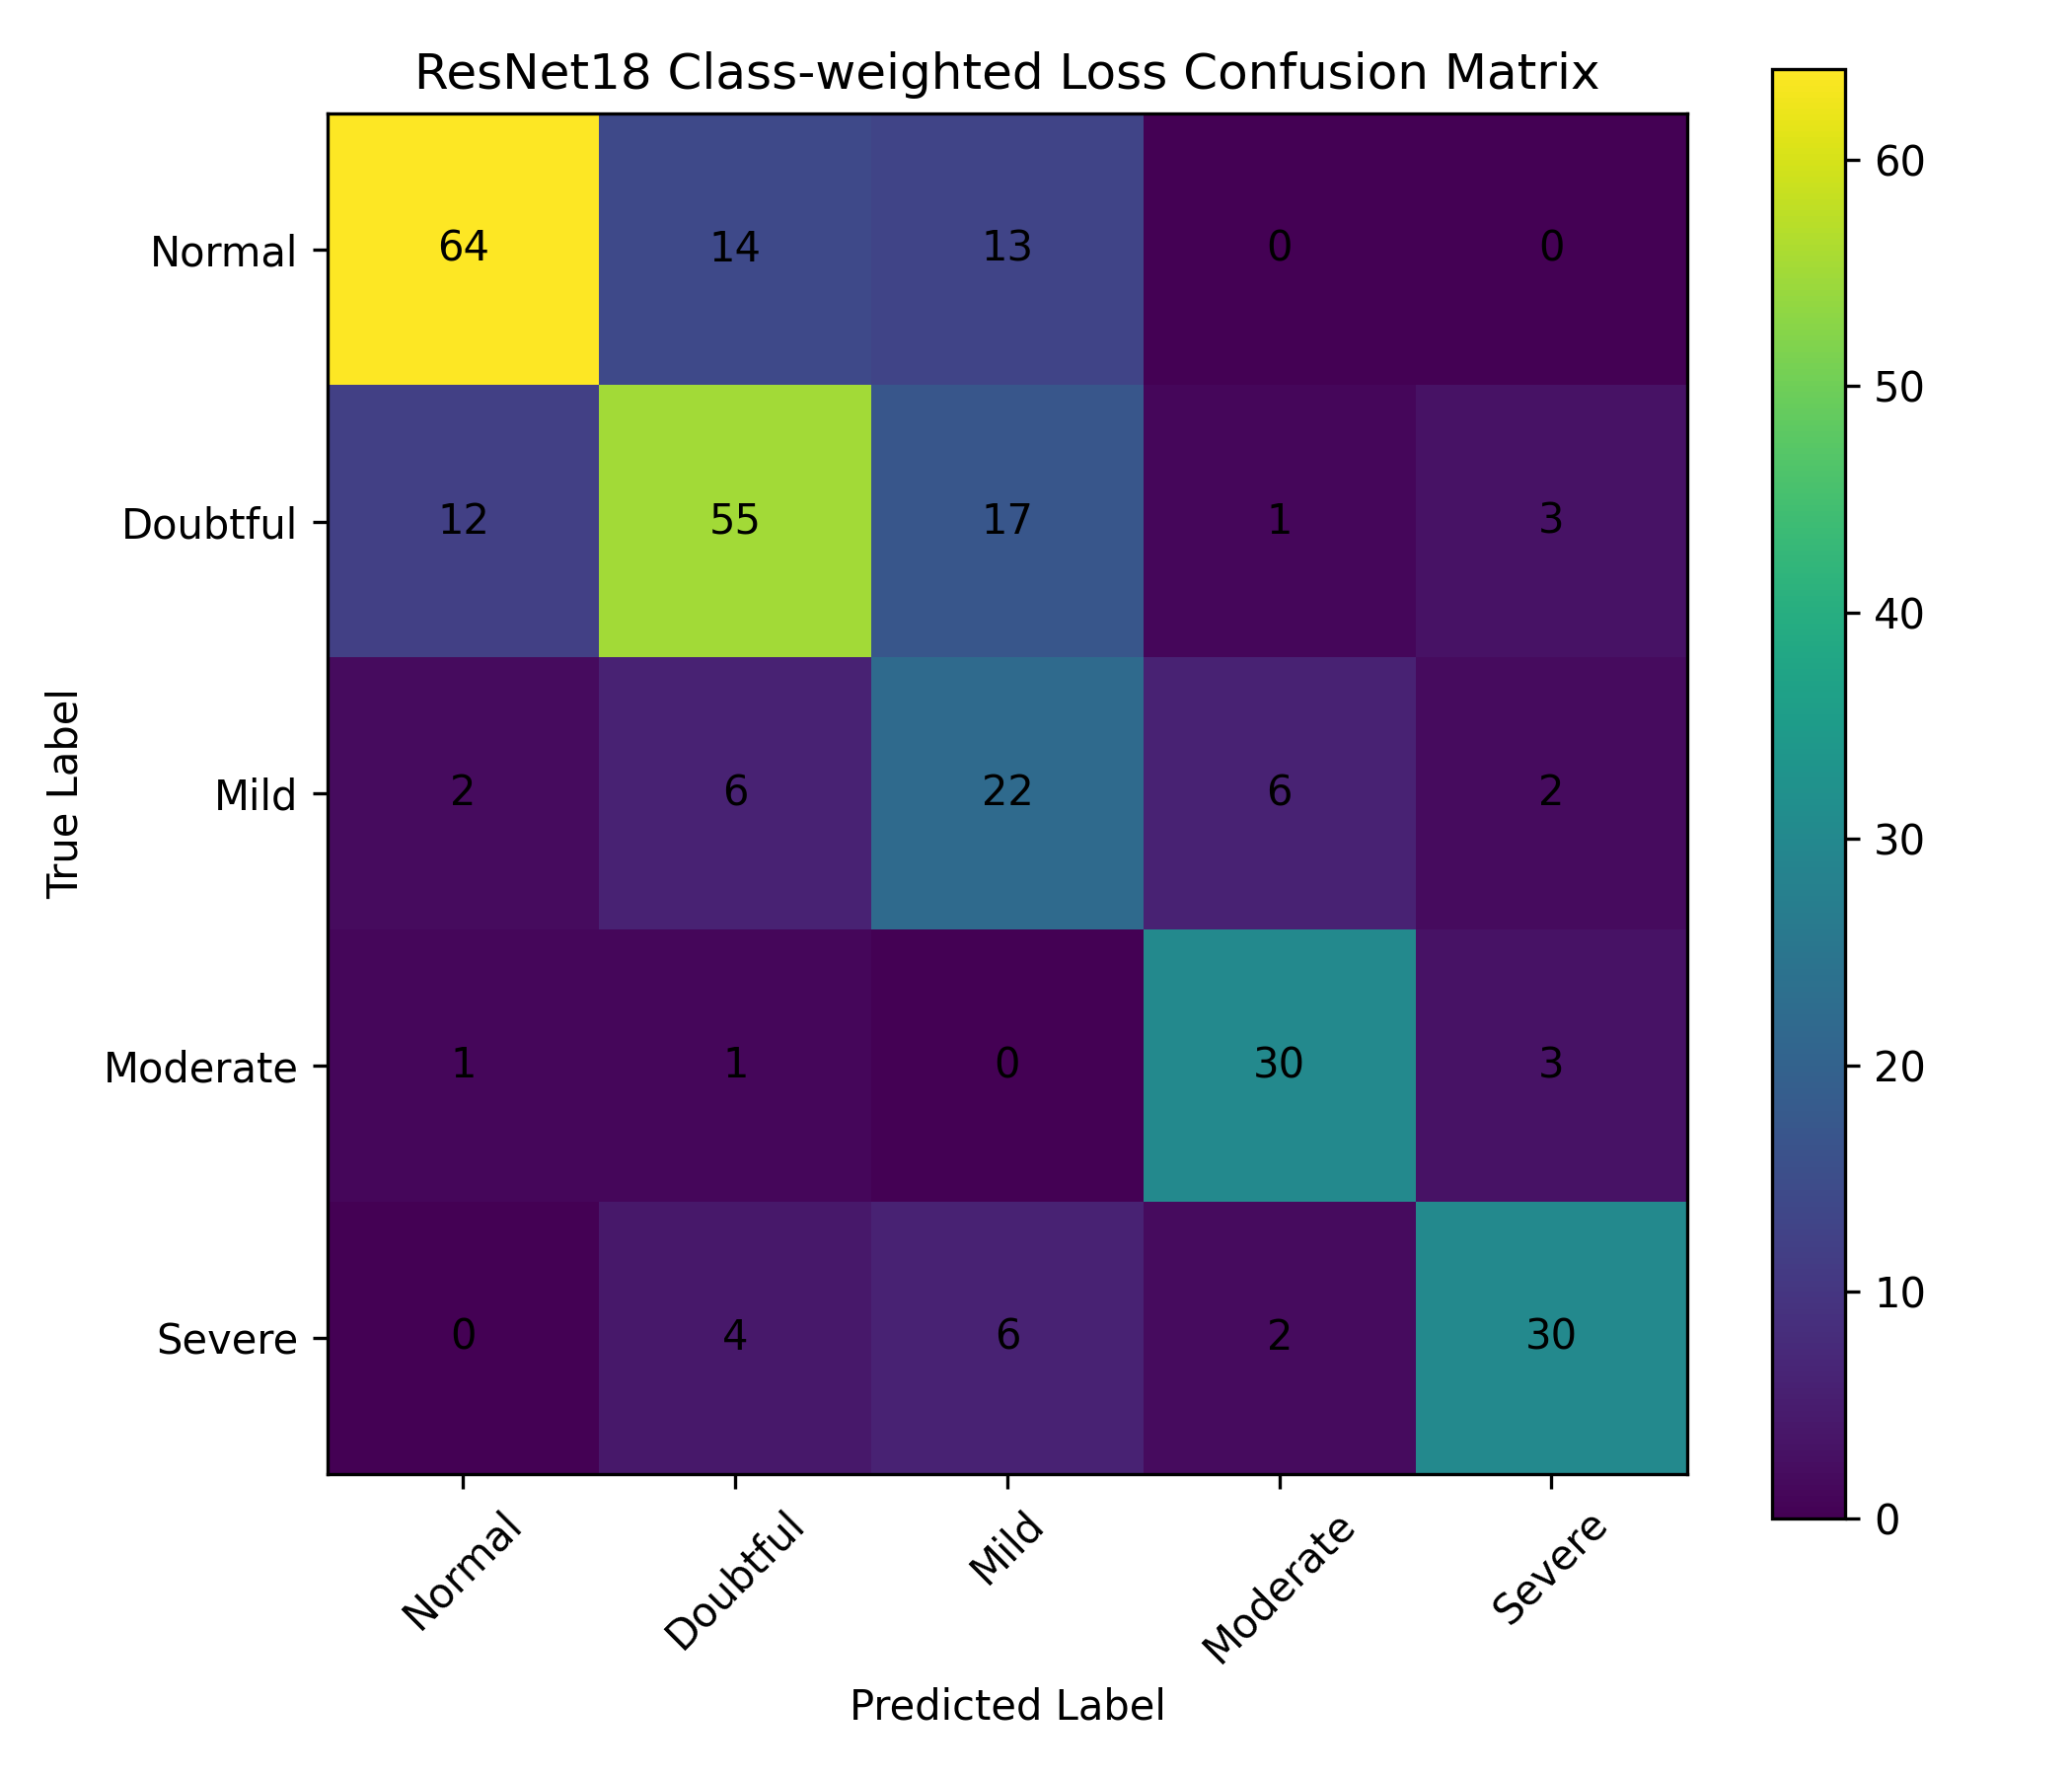


ResNet18 + Ordinal-aware Loss


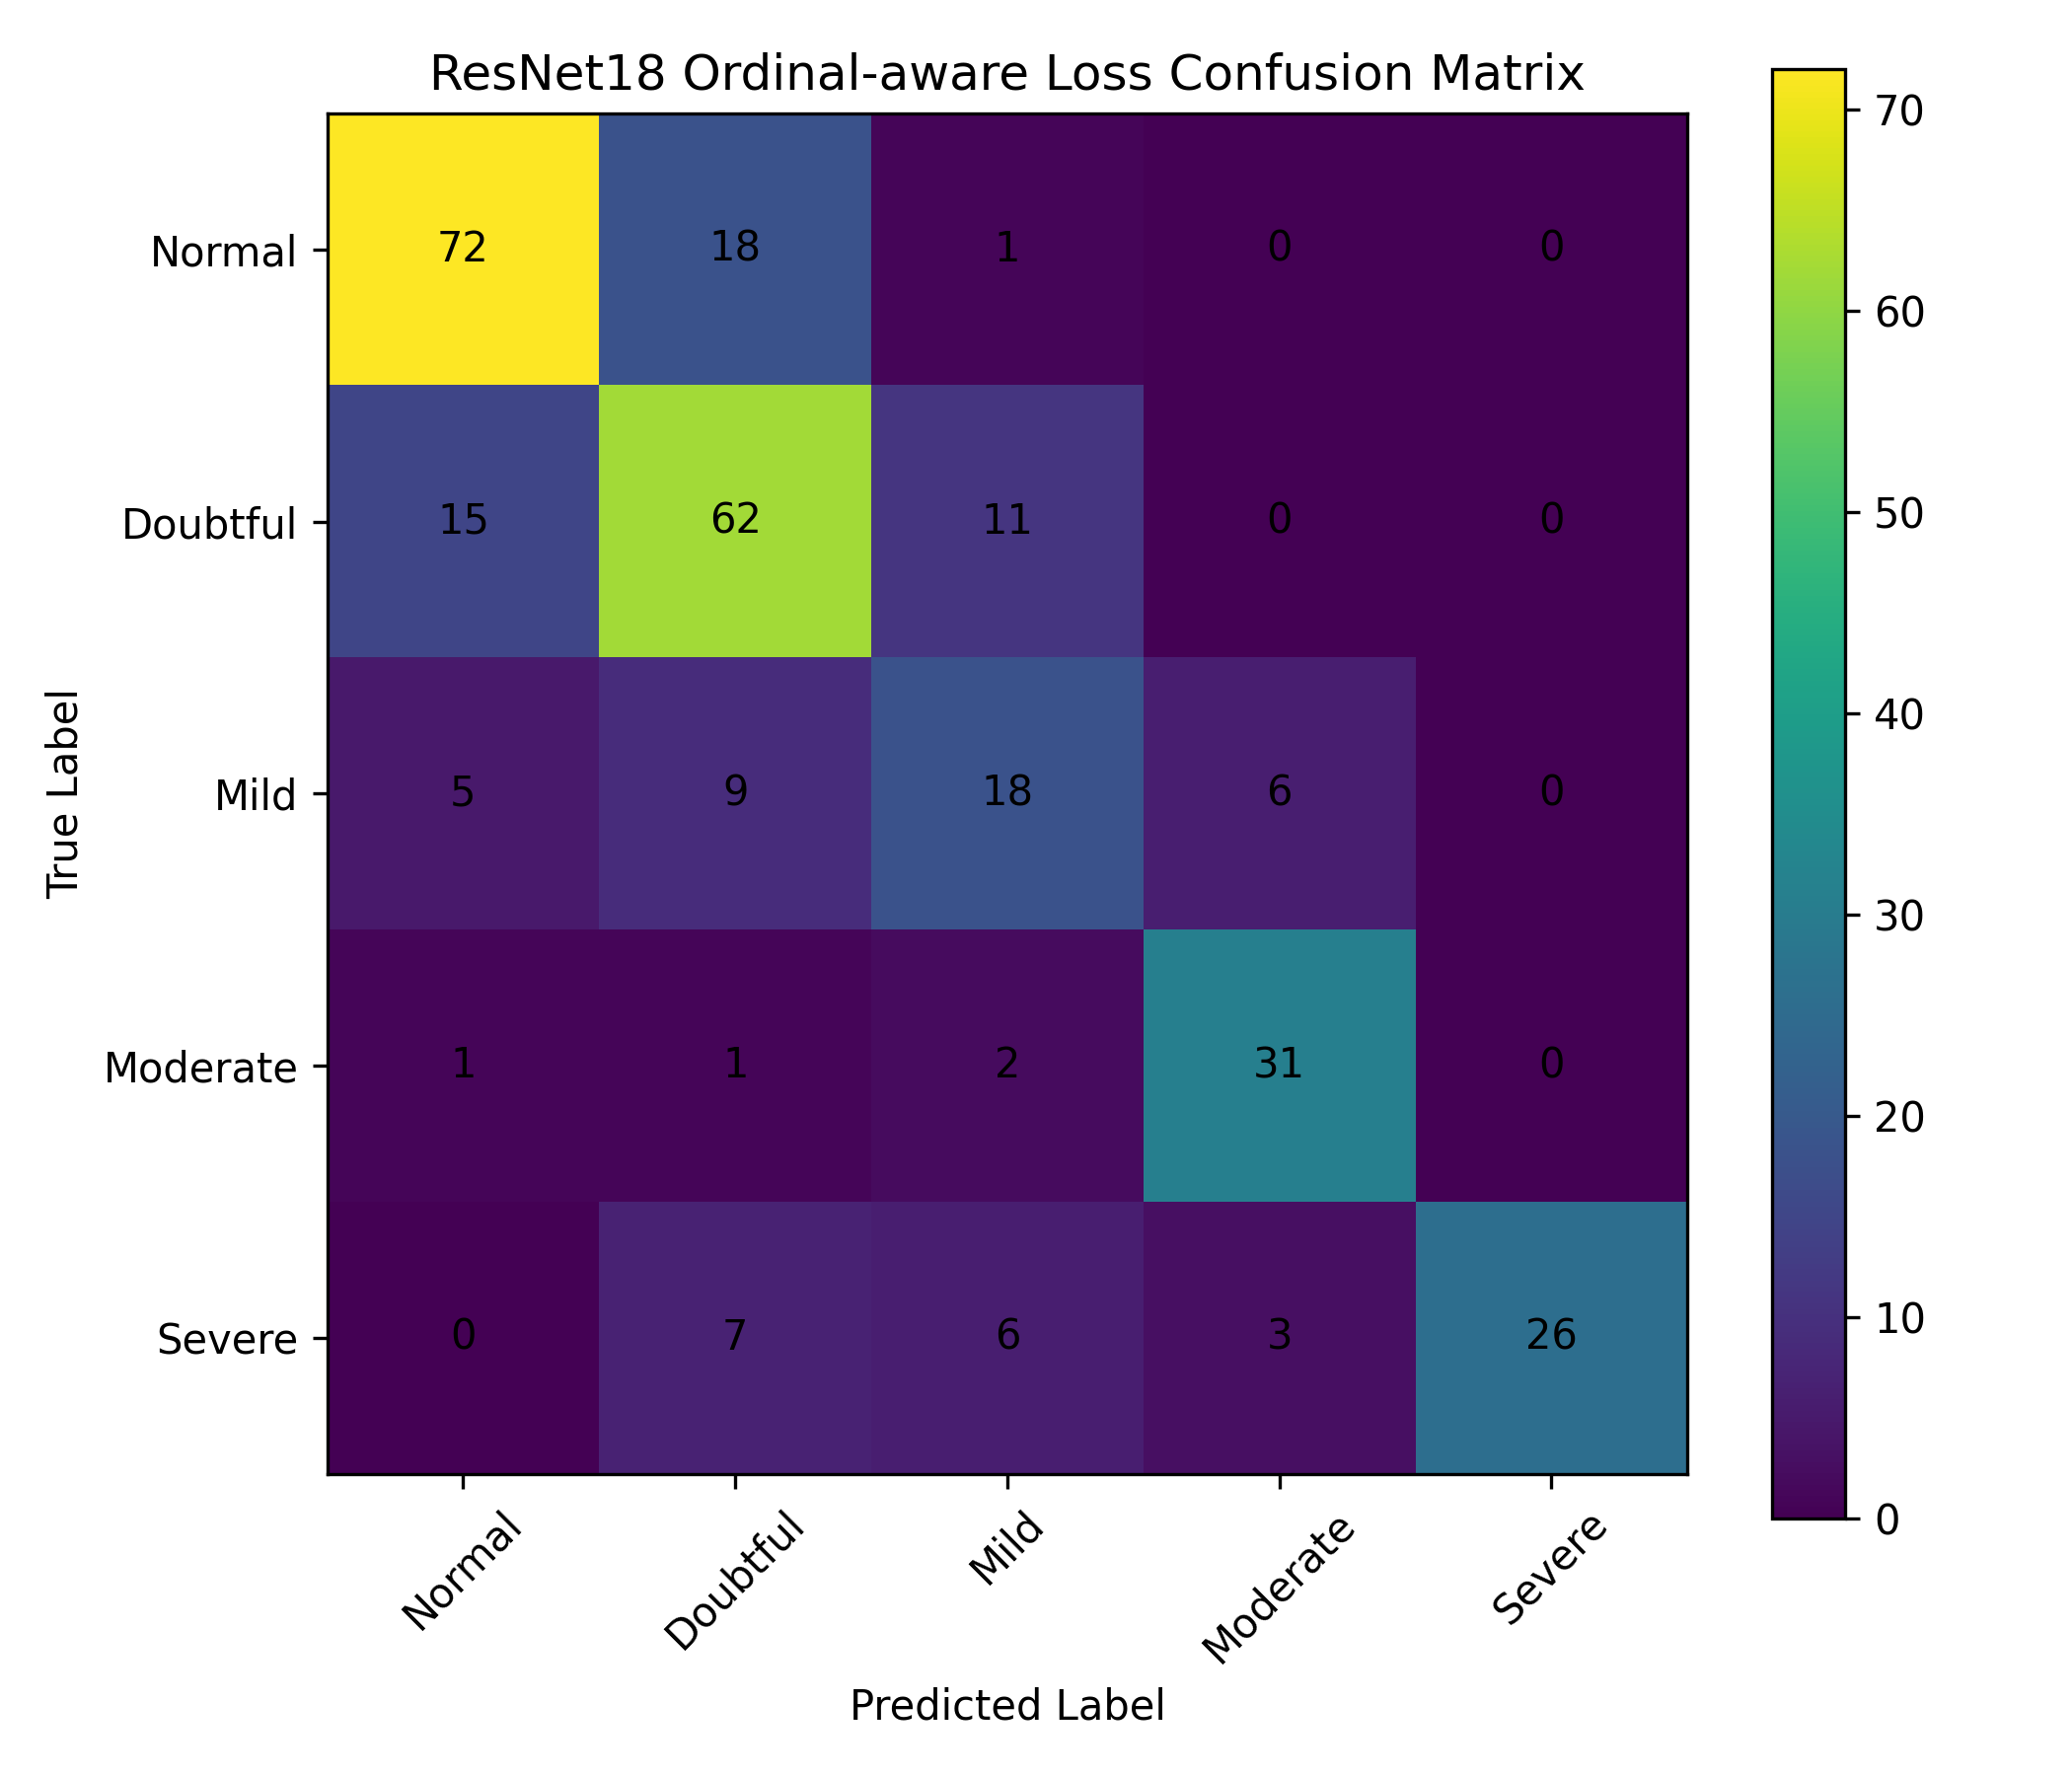

In [9]:
confusion_matrix_figures = {
    "Baseline CNN": FIGURE_DIR / "baseline_confusion_matrix.png",
    "ResNet18 + Standard CE": FIGURE_DIR / "resnet18_confusion_matrix.png",
    "ResNet18 + Class-weighted CE": FIGURE_DIR / "resnet18_classweighted_confusion_matrix.png",
    "ResNet18 + Ordinal-aware Loss": FIGURE_DIR / "resnet18_ordinal_confusion_matrix.png",
}

for title, path in confusion_matrix_figures.items():
    print("\n" + title)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("Missing figure:", path)


In [10]:
if not overall_df.empty:
    best_accuracy = final_comparison.loc[final_comparison["Accuracy"].idxmax()]
    best_macro_f1 = final_comparison.loc[final_comparison["Macro F1"].idxmax()]
    best_mae = final_comparison.loc[final_comparison["MAE"].idxmin()]
    best_qwk = final_comparison.loc[final_comparison["QWK"].idxmax()]
    best_distant = final_comparison.loc[final_comparison["Distant Error Rate"].idxmin()]

    print("Best accuracy:")
    print(best_accuracy[["Experiment", "Accuracy"]].to_string(index=False))

    print("\nBest macro F1:")
    print(best_macro_f1[["Experiment", "Macro F1"]].to_string(index=False))

    print("\nLowest MAE:")
    print(best_mae[["Experiment", "MAE"]].to_string(index=False))

    print("\nBest QWK:")
    print(best_qwk[["Experiment", "QWK"]].to_string(index=False))

    print("\nLowest distant error rate:")
    print(best_distant[["Experiment", "Distant Error Rate"]].to_string(index=False))
else:
    print("Overall metrics are not available.")


Best accuracy:
ResNet18 + Standard CE
                0.7177

Best macro F1:
ResNet18 + Ordinal-aware Loss
                       0.7036

Lowest MAE:
ResNet18 + Ordinal-aware Loss
                       0.3878

Best QWK:
ResNet18 + Ordinal-aware Loss
                       0.8246

Lowest distant error rate:
ResNet18 + Ordinal-aware Loss
                       0.2471
